# MODELLING

## Import the necessary libraries

In [1]:

# Data manipulation


import numpy as np
import pandas as pd


# File handling


from pathlib import Path

# Regular expressions


import re


# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Warnings


import warnings

warnings.filterwarnings("ignore")


# Scikit-learn: Data splitting and cross-validation


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)


# Scikit-learn: Preprocessing


from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline


# Scikit-learn: Models


from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier

# Gradient Boosting Models


from xgboost import XGBClassifier

from lightgbm import LGBMClassifier


# Imbalanced-learn


from imblearn.pipeline import Pipeline as ImbPipeline

from imblearn.over_sampling import SMOTE

# Evaluation metrics


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    brier_score_loss
)


# Calibration


from sklearn.calibration import calibration_curve


# Model interpretation


import shap

# Model saving


import pickle

from datetime import datetime


# Display options


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

## 1. Load the data set after the feature engineering

In [2]:
# Define the output folder
OUTPUT_DIR = Path("./output")
train = pd.read_parquet(
    OUTPUT_DIR / "train_feature_engineered.parquet"
)

test = pd.read_parquet(
    OUTPUT_DIR / "test_feature_engineered.parquet"
)

print(train.shape)
print(test.shape)

(307511, 702)
(48744, 701)


## 2. Inspect the loaded data

In [3]:
# View dataset information
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (307511, 702)
Test shape: (48744, 701)


,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_SUM,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_CREDIT_DAY_OVERDUE_MIN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_DAYS_CREDIT_ENDDATE_MEAN,BUREAU_DAYS_CREDIT_ENDDATE_SUM,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_DAYS_ENDDATE_FACT_MEAN,BUREAU_DAYS_ENDDATE_FACT_SUM,BUREAU_DAYS_ENDDATE_FACT_MIN,BUREAU_DAYS_ENDDATE_FACT_MAX,BUREAU_AMT_CREDIT_MAX_OVERDUE_MEAN,BUREAU_AMT_CREDIT_MAX_OVERDUE_SUM,BUREAU_AMT_CREDIT_MAX_OVERDUE_MIN,BUREAU_AMT_CREDIT_MAX_OVERDUE_MAX,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_CNT_CREDIT_PROLONG_MIN,BUREAU_CNT_CREDIT_PROLONG_MAX,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_SUM,BUREAU_AMT_CREDIT_SUM_MIN,BUREAU_AMT_CREDIT_SUM_MAX,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_SUM,BUREAU_AMT_CREDIT_SUM_DEBT_MIN,BUREAU_AMT_CREDIT_SUM_DEBT_MAX,BUREAU_AMT_CREDIT_SUM_LIMIT_MEAN,BUREAU_AMT_CREDIT_SUM_LIMIT_SUM,BUREAU_AMT_CREDIT_SUM_LIMIT_MIN,BUREAU_AMT_CREDIT_SUM_LIMIT_MAX,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_SUM,BUREAU_AMT_CREDIT_SUM_OVERDUE_MIN,BUREAU_AMT_CREDIT_SUM_OVERDUE_MAX,BUREAU_DAYS_CREDIT_UPDATE_MEAN,BUREAU_DAYS_CREDIT_UPDATE_SUM,BUREAU_DAYS_CREDIT_UPDATE_MIN,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_AMT_ANNUITY_MEAN,BUREAU_AMT_ANNUITY_SUM,BUREAU_AMT_ANNUITY_MIN,BUREAU_AMT_ANNUITY_MAX,BUREAU_BB_MONTHS_COUNT_MEAN,BUREAU_BB_MONTHS_COUNT_SUM,BUREAU_BB_MONTHS_COUNT_MIN,BUREAU_BB_MONTHS_COUNT_MAX,BUREAU_BB_MONTHS_MIN_MEAN,BUREAU_BB_MONTHS_MIN_SUM,BUREAU_BB_MONTHS_MIN_MIN,BUREAU_BB_MONTHS_MIN_MAX,BUREAU_BB_MONTHS_MAX_MEAN,BUREAU_BB_MONTHS_MAX_SUM,BUREAU_BB_MONTHS_MAX_MIN,BUREAU_BB_MONTHS_MAX_MAX,BUREAU_BB_STATUS_0_MEAN,BUREAU_BB_STATUS_0_SUM,BUREAU_BB_STATUS_0_MIN,BUREAU_BB_S

## 3. Check data types

In [4]:
# Check feature types
numeric_cols = train.select_dtypes(include="number").columns.tolist()

categorical_cols = train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

categorical_cols

Numeric columns: 686
Categorical columns: 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

## 4. Separate the target and IDs

In [5]:
# Target variable
y = train["TARGET"]

# IDs
train_ids = train["SK_ID_CURR"]
test_ids = test["SK_ID_CURR"]

# Feature matrices
X = train.drop(columns=["TARGET", "SK_ID_CURR"])
X_test = test.drop(columns=["SK_ID_CURR"])

print(X.shape)
print(X_test.shape)

(307511, 700)
(48744, 700)


## 5. Identify categorical columns

In [6]:
categorical_cols = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Categorical columns: {len(categorical_cols)}")
categorical_cols

Categorical columns: 16


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

## 6. Encoding

#### Step 1: Cardinality check

Check the number of unique categories of each categorical feature. This will help in identfying what type of encoding should I consider

In [7]:
# Check the number of unique values in each categorical feature

cardinality = (
    X[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
    .to_frame(name="Unique Categories")
)

display(cardinality)

,Unique Categories
ORGANIZATION_TYPE,58
OCCUPATION_TYPE,19
NAME_INCOME_TYPE,8
NAME_TYPE_SUITE,8
WALLSMATERIAL_MODE,8
WEEKDAY_APPR_PROCESS_START,7
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
NAME_EDUCATION_TYPE,5
FONDKAPREMONT_MODE,5


### Cardinality Analysis

Cardinality analysis was performed to determine the number of unique categories in each categorical feature before choosing an encoding method. Most categorical variables had a small number of unique categories, ranging from 2 to 19. For example, `NAME_CONTRACT_TYPE`, `FLAG_OWN_CAR`, and `FLAG_OWN_REALTY` had only 2 unique categories, while `OCCUPATION_TYPE` had 19 categories.

The feature with the highest cardinality was `ORGANIZATION_TYPE`, which contained 58 unique categories. To reduce the number of dummy variables created during encoding and improve model efficiency, only the 15 most frequent organization types will be retained, while the remaining less frequent categories will be grouped into a single category labelled **"Other"**.

Overall, the dataset contains mostly low-cardinality categorical variables. Therefore, One-Hot Encoding is an appropriate encoding technique. Grouping the rare `ORGANIZATION_TYPE` categories before encoding helps reduce dimensionality while preserving the most important information in the data.

In [8]:
# Check categories for the two highest-cardinality features

for col in ["ORGANIZATION_TYPE"]:
    print("=" * 60)
    print(f"{col}")
    print("=" * 60)

    print(f"Number of unique categories: {X[col].nunique()}\n")

    display(
        X[col]
        .value_counts(dropna=False)
        .to_frame(name="Count")
    )

ORGANIZATION_TYPE
Number of unique categories: 58



,Count
ORGANIZATION_TYPE,
Business Entity Type 3,67992
XNA,55374
Self-employed,38412
Other,16683
Medicine,11193
Business Entity Type 2,10553
Government,10404
School,8893
Trade: type 7,7831


##### Step 2: Reduce cardinality of ORGANIZATION_TYPE

In [9]:
# Keep the top 15 categories
top_15_org = (
    X["ORGANIZATION_TYPE"]
    .value_counts()
    .nlargest(15)
    .index
)

# Group the rest into "Other"
for df in [X, X_test]:
    df["ORGANIZATION_TYPE"] = np.where(
        df["ORGANIZATION_TYPE"].isin(top_15_org),
        df["ORGANIZATION_TYPE"],
        "Other"
    )

print(X["ORGANIZATION_TYPE"].nunique())
print(X["ORGANIZATION_TYPE"].value_counts())

15
ORGANIZATION_TYPE
Business Entity Type 3    67992
Other                     65016
XNA                       55374
Self-employed             38412
Medicine                  11193
Business Entity Type 2    10553
Government                10404
School                     8893
Trade: type 7              7831
Kindergarten               6880
Construction               6721
Business Entity Type 1     5984
Transport: type 4          5398
Trade: type 3              3492
Industry: type 9           3368
Name: count, dtype: int64


In [10]:
print("Training set:")
print(X["ORGANIZATION_TYPE"].nunique())

print("\nTest set:")
print(X_test["ORGANIZATION_TYPE"].nunique())

Training set:
15

Test set:
15


## 7. Encode categorical features and scale numeric features

In [11]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False,
    dtype="int8"
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols,
    drop_first=False,
    dtype="int8"
)

X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

##### Aligning train and test

In [12]:
# Ensure train and test have identical columns

X, X_test = X.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

#### Verify the encoding

In [13]:
# Recompute feature types

numeric_cols = X.select_dtypes(include="number").columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

Numeric columns: 787
Categorical columns: 0


#### Clean the column names

In [14]:


def clean_column_names(df):
    df = df.copy()

    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]

    return df

In [15]:
X = clean_column_names(X)
X_test = clean_column_names(X_test)

## 8. Train / validation split

##### Splitting  the data

In [16]:


# Split into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Validation features:", X_valid.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_valid.shape)

Training features: (246008, 787)
Validation features: (61503, 787)
Training target: (246008,)
Validation target: (61503,)


##### Verify the class distribution

This confirms that stratification worked correctly.

In [17]:
print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True))

Original target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Training target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


## 9. Handle class imbalance with SMOTE

In [18]:

# Handle Class Imbalance using SMOTE


smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE")
print(y_train.value_counts())

print("\nAfter SMOTE")
print(y_train_smote.value_counts())

Before SMOTE
TARGET
0    226148
1     19860
Name: count, dtype: int64

After SMOTE
TARGET
0    226148
1    226148
Name: count, dtype: int64


In [19]:
print("Duplicate columns:", X.columns.duplicated().sum())

Duplicate columns: 0


To address the class imbalance in the training data, the Synthetic Minority Oversampling Technique (SMOTE) was applied after splitting the dataset into training and validation sets. This ensured that only the training data was balanced, preventing data leakage into the validation set.

## 10. Scale the Data (Logistic Regression Only)

In [20]:

# Feature Scaling

scaler = StandardScaler()

# Logistic Regression
X_train_scaled = scaler.fit_transform(X_train_smote)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test) 

## 11. Create an Evaluation Function
To avoid writing the same evaluation code for every model.

In [ ]:

results = []

def evaluate_model(model_name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": roc_auc
    })

## 12. Train the Baseline Models


#### 1. Logistic Regression

In [22]:

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
log_model.fit(X_train_scaled, y_train_smote)

log_pred = log_model.predict(X_valid_scaled)

log_prob = log_model.predict_proba(X_valid_scaled)[:, 1]

evaluate_model(
    "Logistic Regression",
    y_valid,
    log_pred,
    log_prob
)

Logistic Regression was trained using the scaled SMOTE-balanced training data because it is sensitive to feature magnitudes.

#### 2. Cat boost

In [30]:
catboost_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100
)

catboost_model.fit(
    X_train_smote,
    y_train_smote,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50
)

catboost_pred = (
    catboost_model.predict(X_valid)
    .astype(int)
    .ravel()
)

catboost_prob = catboost_model.predict_proba(X_valid)[:, 1]

evaluate_model(
    "CatBoost",
    y_valid,
    catboost_pred,
    catboost_prob
)

0:	test: 0.6388949	best: 0.6388949 (0)	total: 1.18s	remaining: 5m 51s
100:	test: 0.7604363	best: 0.7604363 (100)	total: 1m 21s	remaining: 2m 40s
200:	test: 0.7719939	best: 0.7719939 (200)	total: 2m 35s	remaining: 1m 16s
299:	test: 0.7771758	best: 0.7771758 (299)	total: 3m 37s	remaining: 0us

bestTest = 0.7771757782
bestIteration = 299



#### 3. Random Forest

In [24]:


rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

rf_pred = rf_model.predict(X_valid)

rf_prob = rf_model.predict_proba(X_valid)[:,1]

evaluate_model(
    "Random Forest",
    y_valid,
    rf_pred,
    rf_prob
)

#### 4. XGBoost

In [25]:


xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_valid)

xgb_prob = xgb_model.predict_proba(X_valid)[:,1]

evaluate_model(
    "XGBoost",
    y_valid,
    xgb_pred,
    xgb_prob
)

#### 5. LightGBM

In [26]:
# Train the original LightGBM model

lgbm_model = LGBMClassifier(
    random_state=42
)

lgbm_model.fit(
    X_train_smote,
    y_train_smote
)
# Generate LightGBM predictions

lgbm_pred = lgbm_model.predict(X_valid)

lgbm_prob = lgbm_model.predict_proba(
    X_valid
)[:, 1]

# Evaluate LightGBM

evaluate_model(
    "LightGBM",
    y_valid,
    lgbm_pred,
    lgbm_prob
)

[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 2.849771 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 133760
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 772
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


Cat Boost, Random Forest, XGBoost, and LightGBM were trained using the SMOTE-balanced training data without feature scaling, as tree-based algorithms are generally not affected by differences in feature scale.

#### Compare the Models

In [31]:
results_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LightGBM,0.919695,0.565000,0.022759,0.043756,0.779973
1,CatBoost,0.920053,0.655844,0.020342,0.039461,0.777176
2,Logistic Regression,0.919760,0.546296,0.035650,0.066931,0.776599
3,XGBoost,0.918801,0.477165,0.061027,0.108214,0.773136
4,Random Forest,0.919288,0.514286,0.003625,0.007200,0.735794


The baseline model comparison shows that **LightGBM achieved the highest ROC-AUC score of 0.779973**, making it the strongest model for predicting loan default based on ranking ability. **CatBoost followed with a ROC-AUC of 0.777176**, performing very closely to LightGBM. Logistic Regression achieved a ROC-AUC of 0.776599, while XGBoost achieved 0.773136. Random Forest performed lower, with a ROC-AUC of 0.735794.

Although LightGBM achieved the highest ROC-AUC, CatBoost recorded the **highest precision at 65.58%**. This means that when CatBoost predicted a customer as a defaulter, its predictions were more likely to be correct. However, its recall was only 2.03%, meaning that it still missed most actual defaulters. LightGBM had a slightly higher recall of 2.28%, while Logistic Regression and XGBoost achieved 3.57% and 6.10% respectively. XGBoost therefore identified more actual defaulters at the default 0.5 threshold, but its precision was lower at 47.72%.

All five models achieved approximately 92% accuracy. However, accuracy is misleading in this case because the dataset is imbalanced, with defaulters representing only about 8% of the data. A model can therefore achieve high accuracy by predicting most customers as non-defaulters while still missing a large proportion of actual defaulters. This is reflected in the very low recall scores across the models.

Since credit risk prediction is an imbalanced classification problem, **ROC-AUC provides a more useful measure of overall model discrimination than accuracy alone**, as it evaluates the model's ability to distinguish between defaulters and non-defaulters across different classification thresholds. Based on the baseline results, **LightGBM was selected as the current best-performing model**, with CatBoost remaining a close alternative. Both models will be further evaluated through hyperparameter tuning before making the final model selection. Particular attention will also be given to classification threshold selection because the default 0.5 threshold results in very low defaulter recall across all models.

## 13. Classification Report

The classification report code was used to evaluate and compare the performance of the five credit-risk models on the validation data. It generates precision, recall, F1-score, and accuracy for both non-defaulters and defaulters. Logistic Regression uses the scaled validation data because it was trained on scaled data, while the tree-based models use the unscaled validation data. The validation data remains untouched by SMOTE, ensuring that the evaluation reflects the models' performance on realistic data.

In [32]:
# CLASSIFICATION REPORTS FOR CURRENT CREDIT RISK MODELS

# Store the models that have already been trained
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": catboost_model
}


# Generate classification reports
for name, model in models.items():

    # Logistic Regression was trained using scaled data
    if name == "Logistic Regression":

        predictions = model.predict(X_valid_scaled)

    # Tree-based models were trained without scaling
    else:

        predictions = model.predict(X_valid)


    # Display model name
    print(f"\n{name} Classification Report")

    print("-" * 60)


    # Display classification report
    print(
        classification_report(
            y_valid,
            predictions,
            target_names=[
                "Non-Defaulter",
                "Defaulter"
            ]
        )
    )


Logistic Regression Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.92      1.00      0.96     56538
    Defaulter       0.55      0.04      0.07      4965

     accuracy                           0.92     61503
    macro avg       0.73      0.52      0.51     61503
 weighted avg       0.89      0.92      0.89     61503


Random Forest Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.92      1.00      0.96     56538
    Defaulter       0.51      0.00      0.01      4965

     accuracy                           0.92     61503
    macro avg       0.72      0.50      0.48     61503
 weighted avg       0.89      0.92      0.88     61503


XGBoost Classification Report
------------------------------------------------------------
               precision    recall  f1-s

Six models were tested on the validation set (56,538 non-defaulters and 4,965 defaulters).

All models except the Decision Tree achieved around 92% accuracy. However, accuracy is misleading in this case because the dataset is imbalanced. Since defaulters make up only about 8% of the validation set, a model can achieve high accuracy while still failing to identify many actual defaulters. Therefore, greater attention is given to the performance of the **Defaulter** class.

- **Logistic Regression**: 55% precision and 4% recall. When the model predicts a customer as a defaulter, it is correct about 55% of the time, but it identifies only a small proportion of actual defaulters.

- **Decision Tree**: 84% accuracy, with the highest defaulter recall at 18%. It identifies more actual defaulters than the other models, but its precision is only 14%, meaning that many customers it classifies as defaulters are actually non-defaulters.

- **Random Forest**: 51% precision and almost 0% recall. Despite achieving around 92% accuracy, the model identifies very few actual defaulters.

- **XGBoost**: 48% precision and 6% recall. It identifies more actual defaulters than Logistic Regression, Random Forest, LightGBM, and CatBoost, but it still misses most actual defaulters.

- **LightGBM**: 56% precision and 2% recall. Its default predictions are relatively precise, but it identifies only a very small proportion of actual defaulters.

- **CatBoost**: 66% precision and 2% recall. It has the highest precision among the six models, meaning that its default predictions are the most precise. However, its recall is still very low, so it misses most actual defaulters.

Overall, all six models perform much better at identifying **non-defaulters** than **defaulters**. No single model performs best across all metrics. The **Decision Tree has the highest defaulter recall (18%)**, while **CatBoost has the highest defaulter precision (66%)**. XGBoost provides a better balance between precision and recall at the current classification threshold, with a defaulter recall of 6% and F1-score of 11%.

These results confirm that **accuracy alone is not an appropriate metric for selecting the final credit-risk model**. Since identifying actual defaulters is particularly important, the next step is to focus on the more promising models, especially **LightGBM and CatBoost**, and perform hyperparameter tuning followed by classification threshold analysis. This will help determine whether their ability to identify defaulters can be improved before selecting the final model.

## 14. ROC Curve comparison for credit risk models


An ROC curve shows how well a model separates the two classes - defaulters vs. non-defaulters - across every possible decision threshold

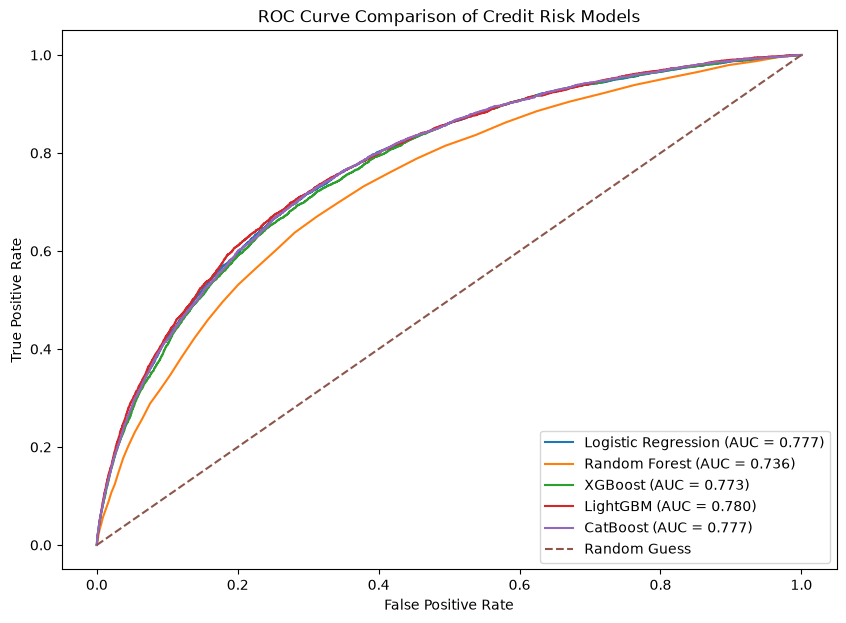

In [33]:
# Create the models dictionary

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": catboost_model
}


# Create the ROC curve figure
plt.figure(figsize=(10, 7))


# Loop through all trained models

for name, model in models.items():

    
    # Logistic Regression uses scaled validation data
    
    # It was trained using X_train_scaled, so the validation data must also be scaled.

    if name == "Logistic Regression":

        # Get probability of the Defaulter class
        probs = model.predict_proba(
            X_valid_scaled
        )[:, 1]

    
    # Tree-based models use original validation data
    
    # Decision Tree, Random Forest, XGBoost, LightGBM and CatBoost
    # were trained without scaling.

    else:

        # Get probability of the Defaulter class
        probs = model.predict_proba(
            X_valid
        )[:, 1]


    # Calculate False Positive Rate and True Positive Rate

    fpr, tpr, _ = roc_curve(
        y_valid,
        probs
    )


    # Calculate ROC-AUC score

    auc = roc_auc_score(
        y_valid,
        probs
    )


    # Plot the ROC curve

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )


# Add the random prediction baseline

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)


# Add axis labels

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")


# Add title

plt.title(
    "ROC Curve Comparison of Credit Risk Models"
)


# Display legend

plt.legend()


# Display the plot

plt.show()

LightGBM (0.780), Logistic Regression (0.777), CatBoost (0.777), and XGBoost (0.773) performed very similarly, showing that they had comparable ability to rank customers according to their risk of default. LightGBM achieved the highest ROC-AUC, but the difference between the top models was very small. Random Forest (0.736) performed noticeably worse than the other models.

Overall, the ROC curves show that all five models performed better than random guessing, but there was no clear winner based on ROC-AUC alone. Therefore, additional metrics such as **precision, recall, F1-score, and classification threshold analysis** were considered to determine which model is most suitable for identifying potential loan defaulters.

## 15. Precision -recall curve comparison

The Precision-Recall curve shows how well the models identify defaulters while avoiding too many false alarms. It is especially useful because the dataset has many more non-defaulters than defaulters.

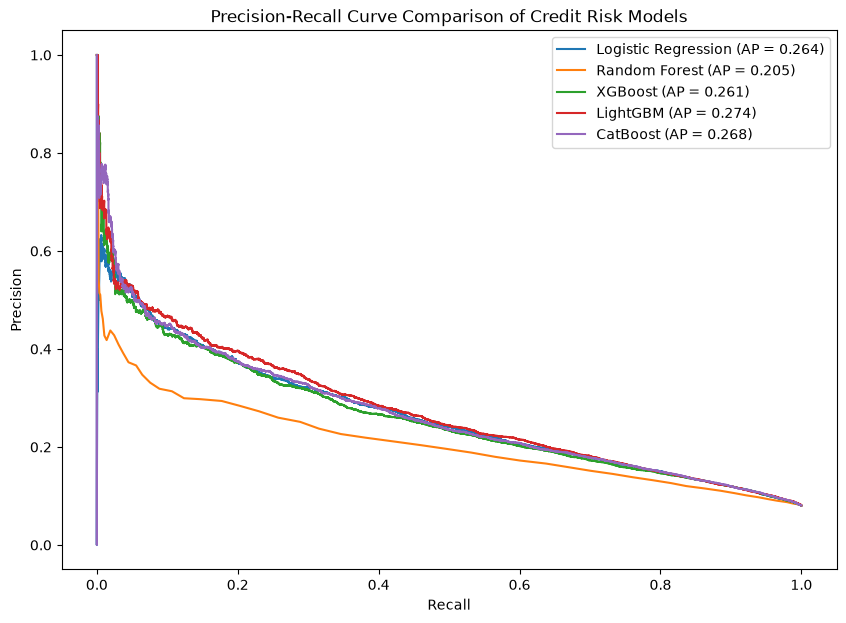

In [34]:

# Create dictionary of trained models

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": catboost_model
}


# Set figure size


plt.figure(figsize=(10, 7))



# Loop through each trained model


for name, model in models.items():

    # Logistic Regression was trained using scaled data
    # Therefore, validation data must also be scaled

    if name == "Logistic Regression":

        probs = model.predict_proba(
            X_valid_scaled
        )[:, 1]

    # Tree-based models were trained without scaling

    else:

        probs = model.predict_proba(
            X_valid
        )[:, 1]


    # Calculate Precision and Recall


    precision, recall, _ = precision_recall_curve(
        y_valid,
        probs
    )

    # Calculate Average Precision (AP)


    ap = average_precision_score(
        y_valid,
        probs
    )


    # Plot the Precision-Recall curve


    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap:.3f})"
    )


# Add axis labels


plt.xlabel("Recall")

plt.ylabel("Precision")


# Add title


plt.title(
    "Precision-Recall Curve Comparison of Credit Risk Models"
)



# Display legend


plt.legend()


# Display the plot


plt.show()

LightGBM (AP = 0.274) achieved the highest Average Precision, followed closely by CatBoost (0.268), Logistic Regression (0.264), and XGBoost (0.261). Random Forest had the lowest Average Precision (0.205), indicating weaker performance in identifying the minority class of defaulters.

The Precision-Recall curves also show the trade-off between precision and recall. As the models are adjusted to identify more potential defaulters and recall increases, precision generally decreases. This means that increasing the number of customers identified as potential defaulters will also result in more false positive predictions.

Overall, **LightGBM performed best based on Average Precision**, although the difference between LightGBM, CatBoost, Logistic Regression, and XGBoost was relatively small. Since the models have low recall at the default 0.5 threshold, **threshold tuning is important** to find a suitable balance between identifying actual defaulters and maintaining acceptable precision.

## 16. Cross-Validated Baseline Comparison 

The leaderboard above is based on a single 80/20 train/validation split. With ROC-AUC scores as close as LightGBM's 0.780 vs. Logistic Regression's 0.777, that ranking could easily be noise from the split itself.

Therefore, the comparison below checks how consistently the five models perform by dividing the training data into five groups and training each model five times, using a different group for validation each time. SMOTE is applied only to the training portion of each group, while the validation portion remains unchanged. Logistic Regression is scaled because it requires scaling, while the tree-based models do not. ROC-AUC is calculated for each run, and the code then calculates the average ROC-AUC and standard deviation to show which model performs best and most consistently.

In [35]:
cv_3fold = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Focus on the strongest baseline models
cv_pipelines = {

    "Logistic Regression": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))
    ]),

    "XGBoost": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", XGBClassifier(
            random_state=42,
            eval_metric="logloss",
            n_jobs=-1
        ))
    ]),

    "LightGBM": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", LGBMClassifier(
            random_state=42,
            verbosity=-1,
            n_jobs=-1
        ))
    ]),

    "CatBoost": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=6,
            loss_function="Logloss",
            eval_metric="AUC",
            random_seed=42,
            verbose=0
        ))
    ])
}


cv_results = []


# Run cross-validation

for name, pipe in cv_pipelines.items():

    print(f"Running {name}...")

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv_3fold,
        scoring="roc_auc",
        n_jobs=1
    )

    cv_results.append({
        "Model": name,
        "CV ROC-AUC Mean": scores.mean(),
        "CV ROC-AUC Std": scores.std()
    })

    print(
        f"{name}: "
        f"ROC-AUC = {scores.mean():.4f} "
        f"(+/- {scores.std():.4f})"
    )


# Create results table

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values(
        "CV ROC-AUC Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

display(cv_results_df)

Running Logistic Regression...
Logistic Regression: ROC-AUC = 0.7722 (+/- 0.0022)
Running XGBoost...
XGBoost: ROC-AUC = 0.7624 (+/- 0.0031)
Running LightGBM...
LightGBM: ROC-AUC = 0.7748 (+/- 0.0022)
Running CatBoost...
CatBoost: ROC-AUC = 0.7692 (+/- 0.0024)


,Model,CV ROC-AUC Mean,CV ROC-AUC Std
0,LightGBM,0.774822,0.002191
1,Logistic Regression,0.772224,0.002241
2,CatBoost,0.769219,0.002384
3,XGBoost,0.762442,0.003075


### Cross-Validation Results

Three-fold stratified cross-validation was performed on the four strongest baseline models using ROC-AUC as the evaluation metric. SMOTE was included inside each pipeline so that oversampling was applied only to the training portion of each fold, while the validation portion remained unchanged.

**LightGBM achieved the highest mean CV ROC-AUC of 0.7748**, followed closely by Logistic Regression at 0.7722. CatBoost achieved 0.7692, while XGBoost recorded the lowest mean ROC-AUC of 0.7624.

The standard deviations were very small for all four models (0.0022–0.0031), indicating that model performance was relatively consistent across the three folds.

Overall, LightGBM remained the strongest model based on cross-validation, although the difference between LightGBM, Logistic Regression, and CatBoost was relatively small. Therefore, CatBoost was retained as a candidate for further improvement rather than being eliminated at this stage.

Based on these results, LightGBM and CatBoost were selected for further hyperparameter tuning. The goal is to determine whether tuning can improve their ability to distinguish between defaulters and non-defaulters before proceeding to classification threshold optimization.

## 17. SMOTE vs. Class-Weighting

SMOTE was used everywhere above, but it's not the only way to handle the 92/8 imbalance, and it's considerably more expensive than simply telling the model to weight the minority class more heavily. Here I train the two strongest baseline families - Logistic Regression and LightGBM - using class_weight='balanced /is_unbalance=True instead of SMOTE, on the *original* (non-resampled) training data, and compare against the SMOTE versions already in results_df.

In [ ]:

# CLASS-WEIGHTING FOR TOP 3 MODELS



# 1. LOGISTIC REGRESSION


log_model_cw = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

# Scale original training data
X_train_scaled_cw = scaler.fit_transform(X_train)

# Scale validation data using the same scaler
X_valid_scaled_cw = scaler.transform(X_valid)

# Train on original imbalanced data
log_model_cw.fit(
    X_train_scaled_cw,
    y_train
)

# Predictions
log_cw_pred = log_model_cw.predict(
    X_valid_scaled_cw
)

log_cw_prob = log_model_cw.predict_proba(
    X_valid_scaled_cw
)[:, 1]

# Evaluate
evaluate_model(
    "Logistic Regression (class_weight)",
    y_valid,
    log_cw_pred,
    log_cw_prob
)


# 2. LIGHTGBM


lgbm_model_cw = LGBMClassifier(
    random_state=42,
    is_unbalance=True,
    verbosity=-1,
    n_jobs=-1
)

# Train on original imbalanced data
lgbm_model_cw.fit(
    X_train,
    y_train
)

# Predictions
lgbm_cw_pred = lgbm_model_cw.predict(
    X_valid
)

lgbm_cw_prob = lgbm_model_cw.predict_proba(
    X_valid
)[:, 1]

# Evaluate
evaluate_model(
    "LightGBM (class_weight)",
    y_valid,
    lgbm_cw_pred,
    lgbm_cw_prob
)


# 3. CATBOOST


catboost_model_cw = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[1, 11.39],
    random_seed=42,
    verbose=100
)

# Train on original imbalanced data
catboost_model_cw.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    early_stopping_rounds=50
)

# Predictions
catboost_cw_pred = (
    catboost_model_cw.predict(X_valid)
    .astype(int)
    .ravel()
)

catboost_cw_prob = (
    catboost_model_cw.predict_proba(X_valid)[:, 1]
)

# Evaluate
evaluate_model(
    "CatBoost (class_weight)",
    y_valid,
    catboost_cw_pred,
    catboost_cw_prob
)


# 4. UPDATED RESULTS TABLE


results_df = (
    pd.DataFrame(results)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_df)

0:	test: 0.7162879	best: 0.7162879 (0)	total: 593ms	remaining: 2m 57s
100:	test: 0.7701736	best: 0.7701736 (100)	total: 57.3s	remaining: 1m 52s
200:	test: 0.7790424	best: 0.7790424 (200)	total: 1m 45s	remaining: 52.2s
299:	test: 0.7835425	best: 0.7835425 (299)	total: 2m 32s	remaining: 0us

bestTest = 0.7835424932
bestIteration = 299



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LightGBM (class_weight),0.726111,0.186047,0.708963,0.294746,0.787347
1,CatBoost (class_weight),0.718485,0.181743,0.710171,0.289420,0.783542
2,LightGBM,0.919695,0.565000,0.022759,0.043756,0.779973
3,CatBoost,0.920053,0.655844,0.020342,0.039461,0.777176
4,Logistic Regression (class_weight),0.711445,0.176961,0.705136,0.282921,0.776778
5,Logistic Regression,0.919760,0.546296,0.035650,0.066931,0.776599
6,XGBoost,0.918801,0.477165,0.061027,0.108214,0.773136
7,Random Forest,0.919288,0.514286,0.003625,0.007200,0.735794


### SMOTE vs Class Weighting

Class weighting was evaluated as an alternative to SMOTE for handling the class imbalance. The results showed a substantial difference in how the models identified defaulters.

The class-weighted LightGBM achieved the highest ROC-AUC of **0.7873**, compared with **0.7800** for the SMOTE-based LightGBM. It also achieved a much higher defaulter recall of **70.90%**, compared with only **2.28%** when SMOTE was used. However, this increase in recall came with a reduction in precision from **56.50% to 18.60%**, indicating a much higher number of false positive predictions.

CatBoost showed a similar pattern. Its class-weighted version achieved a ROC-AUC of **0.7835**, recall of **71.02%**, and F1-score of **28.94%**, compared with a ROC-AUC of **0.7772**, recall of **2.03%**, and F1-score of **3.95%** for the SMOTE-based version.

Logistic Regression also showed a large increase in recall when class weighting was used, from **3.57% to 70.51%**. However, its ROC-AUC improvement was small, increasing from **0.7766 to 0.7768**.

Overall, class weighting produced substantially higher recall and F1-scores than SMOTE for the three models tested. LightGBM with class weighting currently produced the strongest overall result, with the highest ROC-AUC (0.7873) and F1-score (0.2947).

Based on these results, LightGBM and CatBoost with class weighting will be carried forward to hyperparameter tuning. Classification threshold tuning will then be used to find a more suitable balance between precision and recall for the credit-risk objective.

## 18. Hyperparameter tuning

Hyperparameter tuning is important because the default settings are not necessarily the best settings for our dataset. By testing different combinations, we can improve the model's ability to distinguish between customers who are likely to default and those who are not.

In our project, the baseline LightGBM achieved a ROC-AUC of 0.780. Hyperparameter tuning gives the opportunity to improve this performance while also controlling the model's complexity and reducing the risk of overfitting.

In [ ]:

# HYPERPARAMETER TUNING: LIGHTGBM AND CATBOOST
# USING CLASS WEIGHTING


# 1. 3-FOLD STRATIFIED CROSS-VALIDATION


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


# 2. LIGHTGBM HYPERPARAMETER TUNING


lgbm_model_tune = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    is_unbalance=True
)


# LightGBM search space

param_grid_lgbm = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "max_depth": [5, 10, -1],
    "min_child_samples": [50, 100],
    "colsample_bytree": [0.8, 1.0]
}


# Randomized search for LightGBM

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model_tune,
    param_distributions=param_grid_lgbm,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# Run LightGBM tuning

print("\n============================================")
print("TUNING LIGHTGBM")
print("============================================")

lgbm_search.fit(
    X_train,
    y_train
)


# Display best LightGBM parameters

print("\nBest LightGBM Parameters:")
print(lgbm_search.best_params_)

print("\nBest LightGBM Cross-Validation ROC-AUC:")
print(round(lgbm_search.best_score_, 4))


# Retrieve best LightGBM model

best_lgbm = lgbm_search.best_estimator_


# Evaluate tuned LightGBM on untouched validation data

lgbm_tuned_pred = best_lgbm.predict(
    X_valid
)

lgbm_tuned_prob = best_lgbm.predict_proba(
    X_valid
)[:, 1]


evaluate_model(
    "Tuned LightGBM (class_weight)",
    y_valid,
    lgbm_tuned_pred,
    lgbm_tuned_prob
)


# ============================================================
# 3. CATBOOST HYPERPARAMETER TUNING
# ============================================================

catboost_model_tune = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0
)


# CatBoost search space

param_grid_catboost = {
    "iterations": [200, 300, 500],
    "learning_rate": [0.03, 0.05, 0.1],
    "depth": [4, 6, 8],
    "l2_leaf_reg": [3, 5, 7],
    "class_weights": [
        [1, 5],
        [1, 8],
        [1, 10],
        [1, 12],
        [1, 15]
    ]
}


# Randomized search for CatBoost

catboost_search = RandomizedSearchCV(
    estimator=catboost_model_tune,
    param_distributions=param_grid_catboost,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


# Run CatBoost tuning

print("\n============================================")
print("TUNING CATBOOST")
print("============================================")

catboost_search.fit(
    X_train,
    y_train
)


# Display best CatBoost parameters

print("\nBest CatBoost Parameters:")
print(catboost_search.best_params_)

print("\nBest CatBoost Cross-Validation ROC-AUC:")
print(round(catboost_search.best_score_, 4))


# Retrieve best CatBoost model

best_catboost = catboost_search.best_estimator_


# Evaluate tuned CatBoost on untouched validation data

catboost_tuned_pred = (
    best_catboost.predict(X_valid)
    .astype(int)
    .ravel()
)

catboost_tuned_prob = (
    best_catboost.predict_proba(X_valid)[:, 1]
)


evaluate_model(
    "Tuned CatBoost (class_weight)",
    y_valid,
    catboost_tuned_pred,
    catboost_tuned_prob
)



# 4. UPDATED MODEL COMPARISON TABLE


results_df = (
    pd.DataFrame(results)
    .sort_values(
        "ROC-AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_df)


TUNING LIGHTGBM
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best LightGBM Parameters:
{'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 100, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

Best LightGBM Cross-Validation ROC-AUC:
0.7831

TUNING CATBOOST
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best CatBoost Parameters:
{'learning_rate': 0.05, 'l2_leaf_reg': 5, 'iterations': 500, 'depth': 4, 'class_weights': [1, 12]}

Best CatBoost Cross-Validation ROC-AUC:
0.7816


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned LightGBM (class_weight),0.722908,0.185544,0.717623,0.294853,0.788631
1,LightGBM (class_weight),0.726111,0.186047,0.708963,0.294746,0.787347
2,Tuned CatBoost (class_weight),0.705527,0.177952,0.731521,0.286266,0.785721
3,CatBoost (class_weight),0.718485,0.181743,0.710171,0.289420,0.783542
4,LightGBM,0.919695,0.565000,0.022759,0.043756,0.779973
5,CatBoost,0.920053,0.655844,0.020342,0.039461,0.777176
6,Logistic Regression (class_weight),0.711445,0.176961,0.705136,0.282921,0.776778
7,Logistic Regression,0.919760,0.546296,0.035650,0.066931,0.776599
8,XGBoost,0.918801,0.477165,0.061027,0.108214,0.773136
9,Random Forest,0.919288,0.514286,0.003625,0.007200,0.735794


Tuned LightGBM was selected as the leading model because it achieved the highest ROC-AUC, precision, F1-score, and accuracy among the tuned class-weighted models, while maintaining a high defaulter recall of 71.76%. CatBoost achieved slightly higher recall at 73.15%, but this came with lower precision, F1-score, and ROC-AUC.

## 19. Evaluate the tuned class

In [ ]:

# CLASSIFICATION REPORTS FOR TUNED MODELS


# 1. TUNED LIGHTGBM


# Retrieve the best tuned LightGBM model
best_lgbm = lgbm_search.best_estimator_

# Make predictions on untouched validation data
lgbm_tuned_pred = best_lgbm.predict(
    X_valid
)

# Get probability predictions
lgbm_tuned_prob = best_lgbm.predict_proba(
    X_valid
)[:, 1]

# Display LightGBM classification report
print("Tuned LightGBM Classification Report")
print("-" * 60)

print(
    classification_report(
        y_valid,
        lgbm_tuned_pred,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)


# 2. TUNED CATBOOST


# Retrieve the best tuned CatBoost model
best_catboost = catboost_search.best_estimator_

# Make predictions on untouched validation data
catboost_tuned_pred = (
    best_catboost.predict(
        X_valid
    )
    .astype(int)
    .ravel()
)

# Get probability predictions
catboost_tuned_prob = (
    best_catboost.predict_proba(
        X_valid
    )[:, 1]
)

# Display CatBoost classification report
print("\nTuned CatBoost Classification Report")
print("-" * 60)

print(
    classification_report(
        y_valid,
        catboost_tuned_pred,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)

Tuned LightGBM Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.97      0.72      0.83     56538
    Defaulter       0.19      0.72      0.29      4965

     accuracy                           0.72     61503
    macro avg       0.58      0.72      0.56     61503
 weighted avg       0.90      0.72      0.78     61503


Tuned CatBoost Classification Report
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.97      0.70      0.81     56538
    Defaulter       0.18      0.73      0.29      4965

     accuracy                           0.71     61503
    macro avg       0.57      0.72      0.55     61503
 weighted avg       0.90      0.71      0.77     61503



### Tuned Model Classification Reports

The classification reports show that class weighting and hyperparameter tuning substantially improved the models' ability to identify defaulters. Tuned LightGBM achieved a defaulter recall of 72%, while tuned CatBoost achieved a slightly higher recall of 73%. This is a major improvement compared with the baseline models, which had very low defaulter recall.

However, the improvement in recall came with lower precision. Tuned LightGBM achieved 19% precision for the Defaulter class, while CatBoost achieved 18%. This means that although the models are identifying most actual defaulters, many of the customers predicted as defaulters are actually non-defaulters.

Tuned LightGBM achieved slightly better overall performance, with 72% accuracy, 19% defaulter precision, and a 0.29 F1-score. CatBoost achieved 71% accuracy, 18% precision, and a 0.29 F1-score, although its defaulter recall was slightly higher at 73%.

These results show that class weighting successfully reduced the models' tendency to ignore the minority Defaulter class. However, the low precision indicates that there is still a trade-off between detecting more defaulters and generating false alarms. Therefore, threshold tuning will be performed next to determine whether a more suitable balance between precision and recall can be achieved.

## 20. Threshold tuning for tuned lightgbm


Check which probability threshold works best for the LightGBM model. First, it gets the probability that each customer will default. It then tests different thresholds, from 0.50 to 0.10, and converts the probabilities into either default (1) or non-default (0). For each threshold, it calculates accuracy, precision, recall, and F1-score, then puts the results into a table.

In [ ]:

# THRESHOLD TUNING FOR TUNED LIGHTGBM AND CATBOOST


# Thresholds to test
thresholds = [0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.05]


# 1. GET PROBABILITY PREDICTIONS


# Tuned LightGBM probabilities
lgbm_valid_prob = best_lgbm.predict_proba(
    X_valid
)[:, 1]


# Tuned CatBoost probabilities
catboost_valid_prob = best_catboost.predict_proba(
    X_valid
)[:, 1]


# 2. LIGHTGBM THRESHOLD ANALYSIS


lgbm_threshold_results = []


for threshold in thresholds:

    # Convert probabilities into class predictions
    predictions = (
        lgbm_valid_prob >= threshold
    ).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(
        y_valid,
        predictions
    )

    precision = precision_score(
        y_valid,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        predictions,
        zero_division=0
    )

    # Store results
    lgbm_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


# Create LightGBM results table
lgbm_threshold_df = pd.DataFrame(
    lgbm_threshold_results
)


print("\nTUNED LIGHTGBM - THRESHOLD ANALYSIS")
print("=" * 70)

display(
    lgbm_threshold_df.round(4)
)



# 3. CATBOOST THRESHOLD ANALYSIS


catboost_threshold_results = []


for threshold in thresholds:

    # Convert probabilities into class predictions
    predictions = (
        catboost_valid_prob >= threshold
    ).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(
        y_valid,
        predictions
    )

    precision = precision_score(
        y_valid,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_valid,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_valid,
        predictions,
        zero_division=0
    )

    # Store results
    catboost_threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })


# Create CatBoost results table
catboost_threshold_df = pd.DataFrame(
    catboost_threshold_results
)


print("\nTUNED CATBOOST - THRESHOLD ANALYSIS")
print("=" * 70)

display(
    catboost_threshold_df.round(4)
)


TUNED LIGHTGBM - THRESHOLD ANALYSIS


,Threshold,Accuracy,Precision,Recall,F1-score
0,0.50,0.7229,0.1855,0.7176,0.2949
1,0.40,0.6171,0.1512,0.8117,0.2550
2,0.30,0.4852,0.1250,0.8965,0.2195
3,0.20,0.3277,0.1034,0.9549,0.1865
4,0.15,0.2387,0.0942,0.9787,0.1719
5,0.10,0.1498,0.0862,0.9930,0.1586
6,0.05,0.0896,0.0814,0.9998,0.1506



TUNED CATBOOST - THRESHOLD ANALYSIS


,Threshold,Accuracy,Precision,Recall,F1-score
0,0.50,0.7055,0.1780,0.7315,0.2863
1,0.40,0.5860,0.1442,0.8367,0.2460
2,0.30,0.4383,0.1173,0.9130,0.2079
3,0.20,0.2689,0.0969,0.9688,0.1762
4,0.15,0.1826,0.0889,0.9871,0.1632
5,0.10,0.1123,0.0831,0.9970,0.1535
6,0.05,0.0819,0.0808,1.0000,0.1496


### Threshold Tuning Results

Threshold tuning was performed on the tuned LightGBM and CatBoost models to investigate whether changing the default classification threshold of 0.50 could improve the balance between precision and recall.

For both models, lowering the threshold increased recall but substantially reduced precision. For example, lowering the LightGBM threshold from 0.50 to 0.30 increased recall from 71.76% to 89.65%, but precision decreased from 18.55% to 12.50%. The F1-score also decreased from 29.49% to 21.95%.

A similar pattern was observed for CatBoost. Its recall increased from 73.15% at a threshold of 0.50 to 91.30% at a threshold of 0.30, but precision decreased from 17.80% to 11.73%.

The 0.50 threshold produced the highest F1-score for both models. Therefore, based on the thresholds tested, changing the default threshold did not provide a better overall balance between precision and recall.

Tuned LightGBM was selected as the preferred model because it achieved a slightly higher precision, F1-score, accuracy, and ROC-AUC than CatBoost, while maintaining a high defaulter recall of 71.76%.

However, the relatively low precision indicates that the model generates a high number of false positives. This limitation should be considered when interpreting the model's predictions and evaluating its potential use in credit-risk decision making.

## 21. Classification Report - Tuned Lightgbm At 0.5 Threshold

In [ ]:

# FINAL CLASSIFICATION REPORT
# SELECTED MODEL: TUNED LIGHTGBM
# THRESHOLD: 0.50


# Get probability predictions
lgbm_final_prob = best_lgbm.predict_proba(
    X_valid
)[:, 1]


# Apply the selected threshold
lgbm_final_pred = (
    lgbm_final_prob >= 0.50
).astype(int)


# Display classification report
print("FINAL TUNED LIGHTGBM CLASSIFICATION REPORT")
print("Threshold: 0.50")
print("-" * 60)

print(
    classification_report(
        y_valid,
        lgbm_final_pred,
        target_names=[
            "Non-Defaulter",
            "Defaulter"
        ]
    )
)

FINAL TUNED LIGHTGBM CLASSIFICATION REPORT
Threshold: 0.50
------------------------------------------------------------
               precision    recall  f1-score   support

Non-Defaulter       0.97      0.72      0.83     56538
    Defaulter       0.19      0.72      0.29      4965

     accuracy                           0.72     61503
    macro avg       0.58      0.72      0.56     61503
 weighted avg       0.90      0.72      0.78     61503



### Final Tuned LightGBM Classification Report

The final Tuned LightGBM model was evaluated on the untouched validation set using the selected classification threshold of 0.50.

The model achieved an overall accuracy of 72%. For the Defaulter class, the model achieved a recall of 72%, meaning that it correctly identified approximately 72% of customers who actually defaulted. This represents a substantial improvement compared with the baseline models, which had very low defaulter recall.

However, the precision for the Defaulter class was only 19%. This means that a large proportion of customers predicted as defaulters were actually non-defaulters. Therefore, the model successfully identifies a large proportion of actual defaulters, but it does so at the cost of generating many false positive predictions.

For the Non-Defaulter class, the model achieved 97% precision and 72% recall. The weighted F1-score was 0.78.

Overall, the final model provides a much better ability to detect defaulters than the baseline models. However, its relatively low defaulter precision remains an important limitation and should be considered when using the model for credit-risk decisions.

## 22. Save the final model

In [47]:
# Make sure the output folder exists
OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Final selected threshold (chosen from the threshold-tuning section above)
final_threshold = 0.50

model_package = {
    "model": best_lgbm,
    "threshold": final_threshold,
    "training_columns": X_train.columns.tolist(),
    "top_15_organization_types": list(top_15_org),
    "categorical_columns": categorical_cols,
    "clean_column_names_fn": clean_column_names,
    "metadata": {
        "saved_at": datetime.now().isoformat(timespec="seconds"),
        "cv_roc_auc": lgbm_search.best_score_,
        "validation_roc_auc": roc_auc_score(y_valid, lgbm_tuned_prob),
        "best_parameters": lgbm_search.best_params_
    }
}

with open(OUTPUT_DIR / "credit_risk_model.pkl", "wb") as file:
    pickle.dump(model_package, file)

print(f"Model saved to: {(OUTPUT_DIR / 'credit_risk_model.pkl').resolve()}")
print(f"Final threshold: {model_package['threshold']:.2f}")
print(f"Validation ROC-AUC: {model_package['metadata']['validation_roc_auc']:.4f}")
print(f"Training columns: {len(model_package['training_columns'])}")

Model saved to: C:\Users\User\Desktop\final project\output\credit_risk_model.pkl
Final threshold: 0.50
Validation ROC-AUC: 0.7886
Training columns: 787
